# Local/Global Results

Post-hoc, CPU-only results notebook for the local/global track: it aggregates every run under the Drive run root into `_summary/summary.csv`, renders planner-comparison tables, training curves, optimization traces, and refinement outcomes, and saves figures to `_summary/figures/`. It never trains, never plans, and never precomputes latents - launch work from `03_local_global_foundation.ipynb` instead. All cells degrade to friendly messages when artifacts are missing (e.g. when only smoke runs exist).

In [1]:
from pathlib import Path
import csv
import json
import os
import subprocess
import sys


def _resolve_repo() -> Path:
    candidates = []
    try:
        candidates.append(Path.cwd())
    except FileNotFoundError:
        pass  # cwd can vanish when notebook 02/03 re-clones the repo
    candidates.append(Path('/content/wm-prediction'))
    for candidate in candidates:
        if candidate.name == 'notebooks':
            candidate = candidate.parent
        if (candidate / 'src' / 'wm_poc').is_dir():
            return candidate
    raise RuntimeError('Could not locate the wm-prediction repository root.')


REPO = _resolve_repo()
os.chdir(REPO)
if str(REPO / 'src') not in sys.path:
    sys.path.insert(0, str(REPO / 'src'))

DRIVE_ROOT = Path(os.environ.get('WM_POC_DRIVE_ROOT', '/content/drive/MyDrive/wm_poc'))
RUN_ROOT = Path(os.environ.get('LG_RUN_ROOT', str(DRIVE_ROOT / 'logs/local_global')))
SUMMARY_DIR = RUN_ROOT / '_summary'
FIGURE_DIR = SUMMARY_DIR / 'figures'
SUMMARY_CSV = SUMMARY_DIR / 'summary.csv'

# The only subprocess in this notebook; it just reads run directories.
subprocess.run([sys.executable, 'scripts/local_global/summarize_runs.py',
                '--run-root', str(RUN_ROOT), '--out', str(SUMMARY_CSV)], check=False)

from wm_poc.local_global.visualization import (
    aggregate_summary,
    discover_runs,
    find_videos,
    load_planning_logs,
    load_trace,
    load_train_metrics,
    load_val_rollouts,
    plot_optimization_trace,
    plot_planner_bars,
    plot_rollout_errors,
    plot_training_curves,
    refinement_outcomes,
)


def read_summary():
    if not SUMMARY_CSV.is_file():
        return []
    with SUMMARY_CSV.open(encoding='utf-8') as f:
        return list(csv.DictReader(f))


def show_table(rows, columns):
    if not rows:
        print('No runs found yet.')
        return
    present = [c for c in columns if any(r.get(c) not in (None, '') for r in rows)]
    try:
        import pandas as pd
        from IPython.display import display
        display(pd.DataFrame(rows)[present])
    except ImportError:
        widths = {c: max(len(c), *(len(str(r.get(c, ''))) for r in rows)) for c in present}
        print('  '.join(c.ljust(widths[c]) for c in present))
        for row in rows:
            print('  '.join(str(row.get(c, '')).ljust(widths[c]) for c in present))


def show_image(path):
    if path and Path(path).is_file():
        from IPython.display import Image, display
        display(Image(filename=str(path)))
    else:
        print(f'Not generated (missing inputs): {path}')


RUNS = discover_runs(RUN_ROOT)
print(f'Run root: {RUN_ROOT} ({len(RUNS)} runs discovered)')
for run in RUNS:
    print(f'  {run.name}')

Run root: /content/drive/MyDrive/wm_poc/logs/local_global (2 runs discovered)
  pointmaze_local_full_seed0
  smoke_synthetic


## Run summary (all runs and planners)

In [2]:
rows = read_summary()
show_table(rows, [
    'run_name', 'planner', 'train_steps', 'final_val_loss', 'num_episodes',
    'success_rate', 'mean_normalized_final_distance', 'mean_final_latent_distance_global',
    'mean_reference_final_distance_global', 'mean_planning_wall_time_sec',
])

,run_name,planner,train_steps,final_val_loss,success_rate,mean_normalized_final_distance,mean_final_latent_distance_global,mean_reference_final_distance_global,mean_planning_wall_time_sec
0,pointmaze_local_full_seed0,global_cem,20000,0.005800384533358738,0.97,0.13840896536729036,0.014482790092006325,0.05834840893745422,231.64024022880997
1,pointmaze_local_full_seed0,hybrid_cem_local_refine,20000,0.005800384533358738,0.54,0.6319047128389382,0.07946422439999878,0.05834840893745422,234.1174413351498
2,pointmaze_local_full_seed0,hybrid_cem_local_refine_global_rescore,20000,0.005800384533358738,0.97,0.1381835395995974,0.014508418822661042,0.05834840893745422,234.17096507802933
3,pointmaze_local_full_seed0,local_adam,20000,0.005800384533358738,0.41,0.6986892023737599,0.09143996981903911,0.05834840893745422,2.674546452060276
4,pointmaze_local_full_seed0,local_cem,20000,0.005800384533358738,0.45,0.6745333815966926,0.08781714791432023,0.05834840893745422,0.2246516361499016
5,pointmaze_local_full_seed0,local_gd,20000,0.005800384533358738,0.13,1.3056728870786092,0.14439783740788698,0.05834840893745422,2.6045348876999923
6,smoke_synthetic,,200,0.001913723797770217,,,,,


## Local surrogate training curves

Solid = validation, dashed = train, log scale; parsed from each run's `metrics/train_metrics.jsonl`.

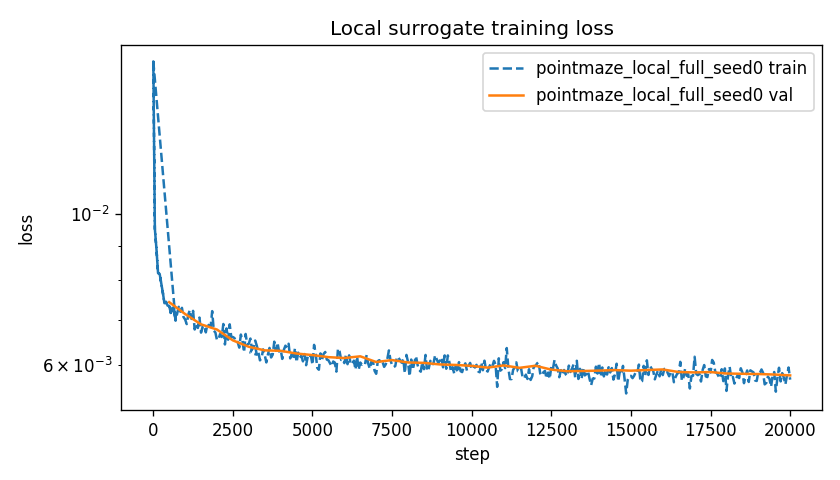

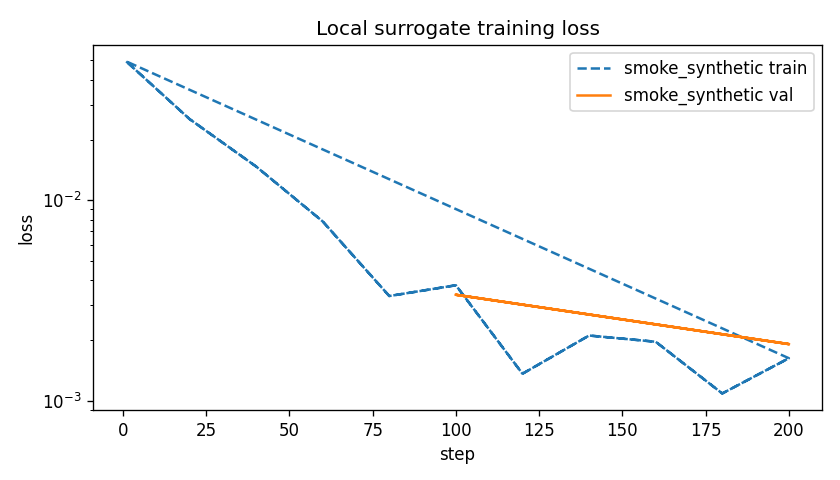

In [3]:
shown = False
for run_dir in RUNS:
    train_rows = load_train_metrics(run_dir)
    if not train_rows:
        continue
    out = plot_training_curves(train_rows, FIGURE_DIR / f'{run_dir.name}_training.png', label=run_dir.name)
    if out is not None:
        show_image(out)
        shown = True
if not shown:
    print('No training metrics found yet; train a surrogate in notebook 03 first.')

## Multi-step rollout error

Validation MSE per rollout horizon (local space), first vs latest logged evaluation - rising curves over the horizon are expected; the question is how fast they grow.

pointmaze_local_full_seed0


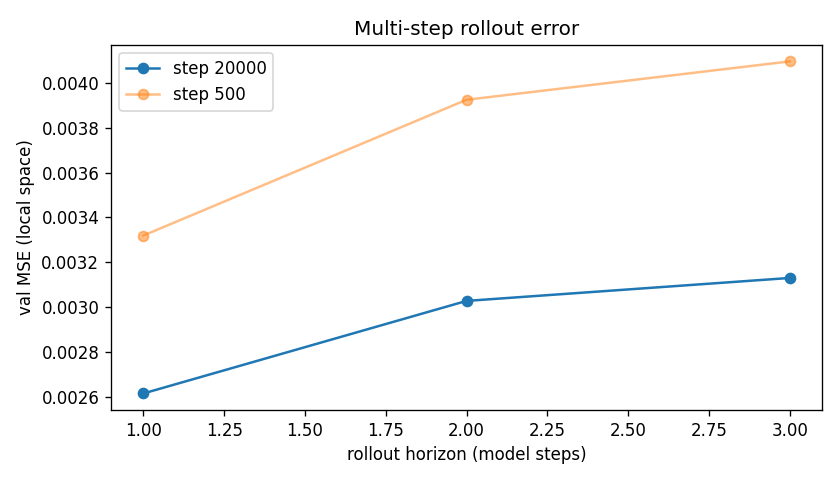

smoke_synthetic


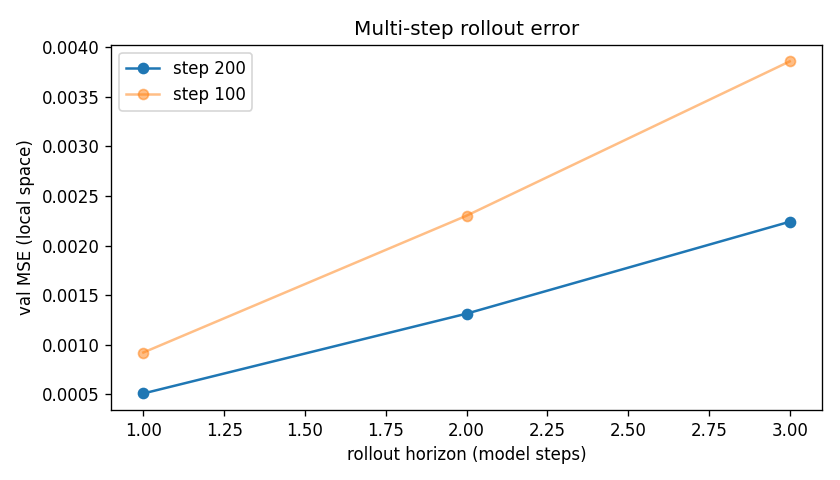

In [4]:
shown = False
for run_dir in RUNS:
    val_rows = load_val_rollouts(run_dir)
    out = plot_rollout_errors(val_rows, FIGURE_DIR / f'{run_dir.name}_rollout_error.png')
    if out is not None:
        print(run_dir.name)
        show_image(out)
        shown = True
if not shown:
    print('No validation rollout logs found yet.')

## Planner comparison

Success rate and normalized final distance, with compute columns so the comparison is fair: global CEM spends global forward calls; local planners spend backward steps; hybrids spend both. The offline episodes are scored by the global model itself, which structurally favors `global_cem` on distance - efficiency columns carry the local/global signal.

,run_name,planner,complete,episodes_completed,episodes_requested,success_rate,mean_normalized_final_distance,mean_planning_wall_time_sec,total_global_forward_calls,total_local_forward_calls,total_backward_steps,accepted_refinement_rate,action_bound_violation_count
0,pointmaze_local_full_seed0,global_cem,True,100,100,0.97,0.13840896536729036,231.64024022880997,1500500,0,0,,0
1,pointmaze_local_full_seed0,hybrid_cem_local_refine,True,100,100,0.54,0.6319047128389382,234.1174413351498,1501000,50000,50000,1.0,0
2,pointmaze_local_full_seed0,hybrid_cem_local_refine_global_rescore,True,100,100,0.97,0.1381835395995974,234.17096507802933,1501000,50000,50000,0.028000000000000004,0
3,pointmaze_local_full_seed0,local_adam,True,100,100,0.41,0.6986892023737599,2.674546452060276,0,50000,50000,,0
4,pointmaze_local_full_seed0,local_cem,True,100,100,0.45,0.6745333815966926,0.2246516361499016,0,1500500,0,,0
5,pointmaze_local_full_seed0,local_gd,True,100,100,0.13,1.3056728870786092,2.6045348876999923,0,50000,50000,,0


complete=False rows are summarized over episodes_completed so far (mid-run);
their numbers tighten as more episodes finish -- re-run this notebook to refresh.


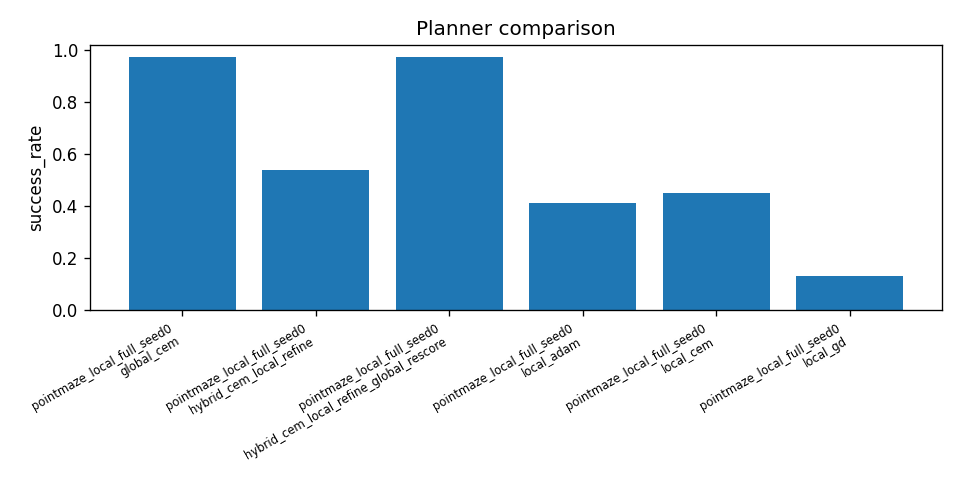

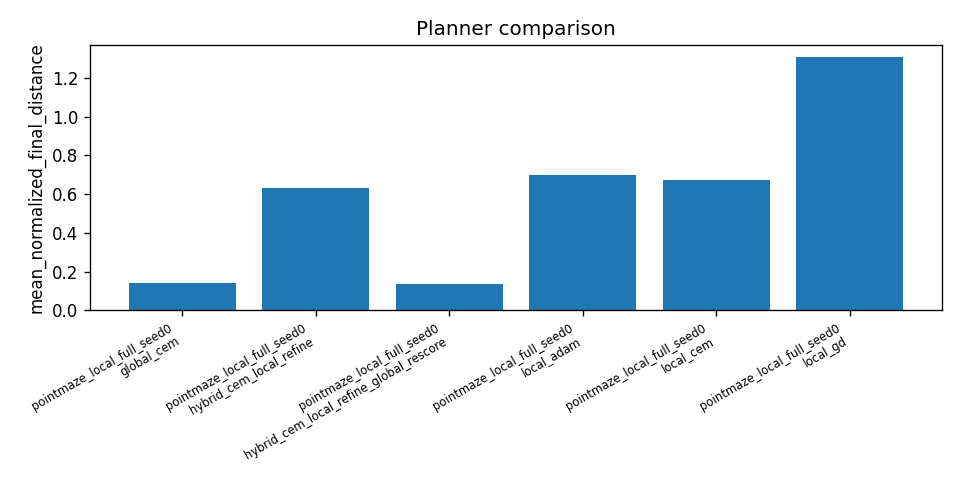

In [5]:
rows = read_summary()
planner_rows = [r for r in rows if r.get('planner')]
show_table(planner_rows, [
    'run_name', 'planner', 'complete', 'episodes_completed', 'episodes_requested',
    'success_rate', 'mean_normalized_final_distance',
    'mean_planning_wall_time_sec', 'total_global_forward_calls',
    'total_local_forward_calls', 'total_backward_steps',
    'accepted_refinement_rate', 'action_bound_violation_count',
])
print('complete=False rows are summarized over episodes_completed so far (mid-run);')
print('their numbers tighten as more episodes finish -- re-run this notebook to refresh.')
summary_rows = aggregate_summary(RUN_ROOT)
show_image(plot_planner_bars(summary_rows, FIGURE_DIR / 'planner_success.png', metric='success_rate'))
show_image(plot_planner_bars(summary_rows, FIGURE_DIR / 'planner_norm_distance.png',
                             metric='mean_normalized_final_distance'))

## Planner optimization traces

Cost vs optimizer iteration for a representative episode per planner (CEM best-cost per iteration; GD/Adam cost per step; hybrid shows the CEM stage followed by the local refinement stage).

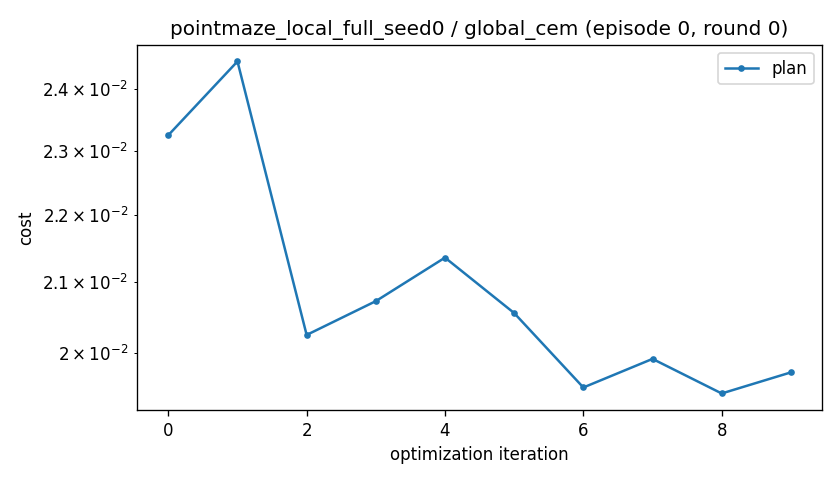

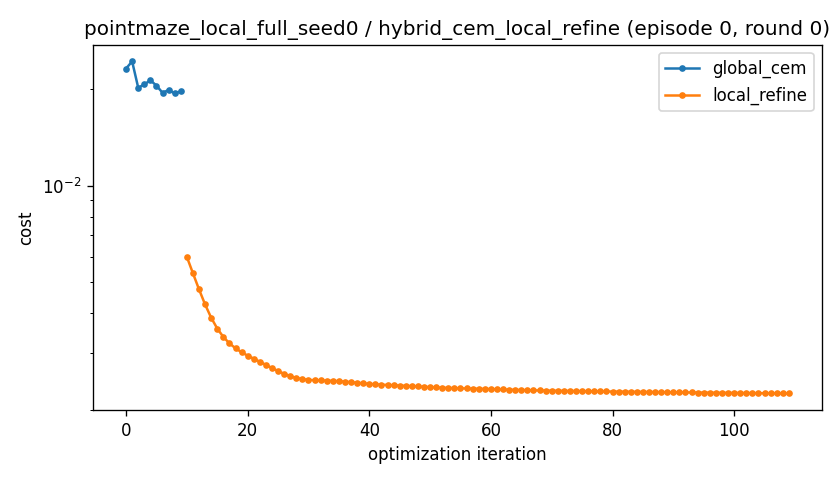

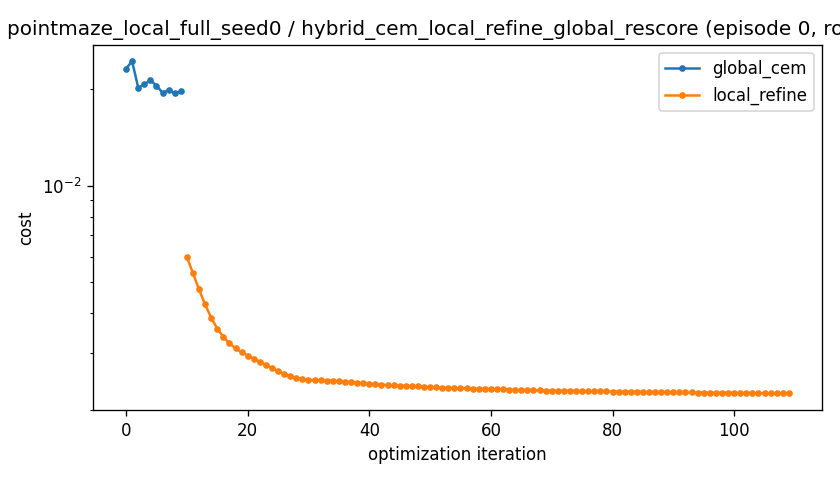

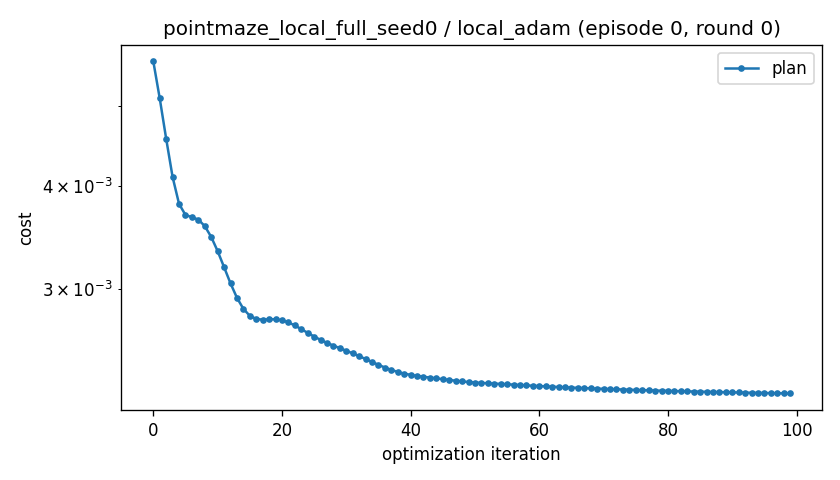

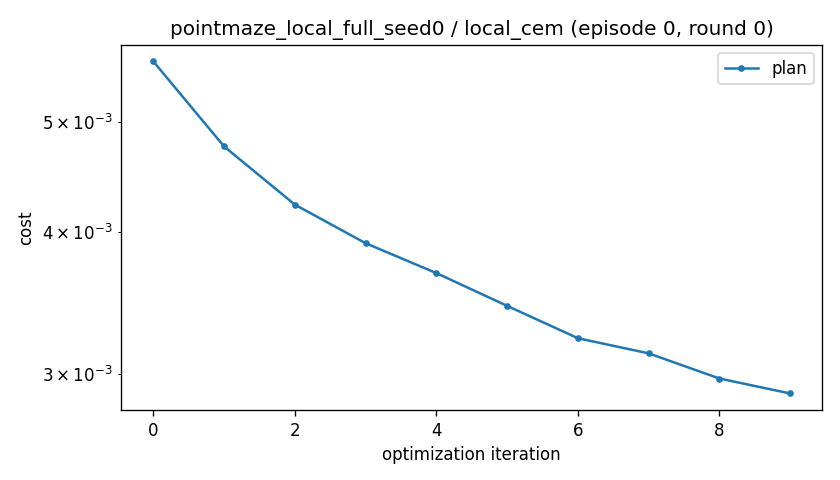

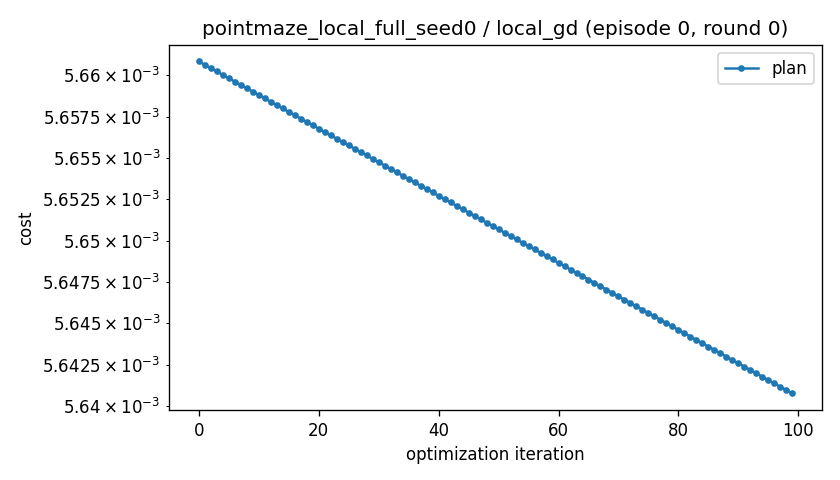

In [6]:
shown = False
for run_dir in RUNS:
    for planner_name, info in load_planning_logs(run_dir).items():
        if not info['trace_files']:
            continue
        trace_rows = load_trace(info['trace_files'][0])
        out = plot_optimization_trace(
            trace_rows,
            FIGURE_DIR / f'{run_dir.name}_{planner_name}_trace.png',
            title=f'{run_dir.name} / {planner_name} (episode 0, round 0)',
        )
        if out is not None:
            show_image(out)
            shown = True
if not shown:
    print('No planner traces found yet; run a planning evaluation in notebook 03 first.')

## Qualitative videos

The first-version evaluation is offline (latent-space goal reaching), so no environment videos are produced by this track yet; DINO-WM `plan.py` videos from notebook 02 remain the qualitative reference. Any future videos under `planning/<planner>/videos/` are picked up automatically.

In [7]:
from IPython.display import HTML, Video, display

MAX_VIDEOS = 4
shown = 0
for run_dir in RUNS:
    for video in find_videos(run_dir)[: max(0, MAX_VIDEOS - shown)]:
        display(HTML(f'<b>{run_dir.name} / {video.parent.parent.name} / {video.name}</b>'))
        display(Video(str(video), embed=True, width=320))
        shown += 1
if shown == 0:
    print('No planning videos found (expected for the offline latent evaluation).')

No planning videos found (expected for the offline latent evaluation).


## Refinement outcomes (hybrid planners)

Per planning round: did local gradient refinement improve the trusted global cost, and did the re-score gate accept it? High rejection rates mean the surrogate's gradients point away from what the global model considers progress (the local-vs-global disagreement signal).

In [8]:
all_outcomes = []
for run_dir in RUNS:
    for outcome in refinement_outcomes(run_dir):
        all_outcomes.append({'run_name': run_dir.name, **outcome})
if not all_outcomes:
    print('No hybrid planner traces found yet.')
else:
    improved = [o for o in all_outcomes if o.get('refinement_improved_global_cost')]
    rejected = [o for o in all_outcomes if o.get('accepted_refinement') is False]
    print(f"{len(all_outcomes)} hybrid planning rounds: "
          f"{len(improved)} improved the global cost, {len(rejected)} rejected by re-score.")
    worst = sorted(
        (o for o in all_outcomes if o.get('global_rescore_cost') and o.get('cem_global_cost')),
        key=lambda o: o['global_rescore_cost'] / max(o['cem_global_cost'], 1e-12),
        reverse=True,
    )
    show_table(worst[:10], [
        'run_name', 'planner', 'episode_file', 'round', 'cem_global_cost',
        'global_rescore_cost', 'refinement_improved_global_cost', 'accepted_refinement',
    ])

1000 hybrid planning rounds: 12 improved the global cost, 486 rejected by re-score.


,run_name,planner,episode_file,round,cem_global_cost,global_rescore_cost,refinement_improved_global_cost,accepted_refinement
0,pointmaze_local_full_seed0,hybrid_cem_local_refine_global_rescore,episode_089.jsonl,1,0.013639,0.240326,False,False
1,pointmaze_local_full_seed0,hybrid_cem_local_refine,episode_093.jsonl,2,0.014565,0.255658,False,True
2,pointmaze_local_full_seed0,hybrid_cem_local_refine,episode_064.jsonl,3,0.013760,0.238941,False,True
3,pointmaze_local_full_seed0,hybrid_cem_local_refine,episode_089.jsonl,1,0.014409,0.244563,False,True
4,pointmaze_local_full_seed0,hybrid_cem_local_refine,episode_061.jsonl,3,0.011398,0.189564,False,True
5,pointmaze_local_full_seed0,hybrid_cem_local_refine,episode_093.jsonl,3,0.013880,0.229267,False,True
6,pointmaze_local_full_seed0,hybrid_cem_local_refine_global_rescore,episode_095.jsonl,2,0.013170,0.209895,False,False
7,pointmaze_local_full_seed0,hybrid_cem_local_refine,episode_095.jsonl,3,0.013252,0.208952,False,True
8,pointmaze_local_full_seed0,hybrid_cem_local_refine_global_rescore,episode_095.jsonl,1,0.013488,0.206928,False,False
9,pointmaze_local_full_seed0,hybrid_cem_local_refine_global_rescore,episode_018.jsonl,2,0.012907,0.197996,False,False


## Recommendation

In [9]:
rows = [r for r in aggregate_summary(RUN_ROOT)
        if r.get('planner') and r.get('success_rate') is not None]
if not rows:
    print('No planner evaluations yet - run the planning comparison in notebook 03 first.')
else:
    def sort_key(row):
        return (
            -float(row['success_rate']),
            float(row.get('mean_normalized_final_distance') or 1e9),
            float(row.get('mean_planning_wall_time_sec') or 1e9),
        )

    ranked = sorted(rows, key=sort_key)
    print('Ranking by success rate, then normalized final distance, then wall time:')
    for row in ranked:
        tag = '' if row.get('complete') else f"  [PARTIAL n={row.get('episodes_completed')}]"
        print(f"  {row['run_name']:<30} {row['planner']:<42} "
              f"success={float(row['success_rate']):.2f} "
              f"norm_dist={float(row.get('mean_normalized_final_distance') or float('nan')):.3f} "
              f"time={float(row.get('mean_planning_wall_time_sec') or float('nan')):.2f}s{tag}")
    print()
    complete_ranked = [r for r in ranked if r.get('complete')]
    if complete_ranked:
        best = complete_ranked[0]
        print(f"Recommendation (among completed planners): use '{best['planner']}' "
              f"(run {best['run_name']}) next.")
    else:
        print('All planners are still partial; the ranking above is provisional until the')
        print('runs complete. Re-run this notebook as more episodes finish.')
    print('Caveat: offline episodes are scored by the global model itself, which')
    print('structurally favors global_cem on distance. Treat local/hybrid wins on wall')
    print('time, backward-step efficiency, and re-score acceptance as the actionable')
    print('signal, and confirm with a real-environment evaluation (DINO-WM plan.py)')
    print('before locking in a planner.')

Ranking by success rate, then normalized final distance, then wall time:
  pointmaze_local_full_seed0     hybrid_cem_local_refine_global_rescore     success=0.97 norm_dist=0.138 time=234.17s
  pointmaze_local_full_seed0     global_cem                                 success=0.97 norm_dist=0.138 time=231.64s
  pointmaze_local_full_seed0     hybrid_cem_local_refine                    success=0.54 norm_dist=0.632 time=234.12s
  pointmaze_local_full_seed0     local_cem                                  success=0.45 norm_dist=0.675 time=0.22s
  pointmaze_local_full_seed0     local_adam                                 success=0.41 norm_dist=0.699 time=2.67s
  pointmaze_local_full_seed0     local_gd                                   success=0.13 norm_dist=1.306 time=2.60s

Recommendation (among completed planners): use 'hybrid_cem_local_refine_global_rescore' (run pointmaze_local_full_seed0) next.
Caveat: offline episodes are scored by the global model itself, which
structurally favors global_